In [17]:
# ============================================================
# VALIDACIÓN DEL FEATURE SPACE (Bandas Only)
# ============================================================

print("=" * 60)
print("DEBUG FEATURE SPACE")
print("=" * 60)

print(f"Shape X_original: {X_original.shape}")
print(f"Número de features: {X_original.shape[1]}")

expected_features = 19 * 3  # 19 canales × Theta/Alpha/Beta

print(f"Features esperadas: {expected_features}")

if X_original.shape[1] != expected_features:
    print("\n❌ ERROR CRÍTICO:")
    print("El espacio de features NO corresponde al experimento bandsonly.")
    print("Probablemente estás cargando features del experimento viejo.")
else:
    print("\n✅ Feature space consistente con bandsonly.")

DEBUG FEATURE SPACE
Shape X_original: (143899, 57)
Número de features: 57
Features esperadas: 57

✅ Feature space consistente con bandsonly.


In [18]:
# ============================================================
# CÁLCULO CORRECTO DE STATE PROFILES (ESCALADOS)
# ============================================================

import joblib

# Cargar scaler EXACTO del experimento actual
scaler_path = os.path.join(exp_dir, 'scaler.pkl')

print(f"Cargando scaler desde:\n{scaler_path}")

scaler = joblib.load(scaler_path)

# IMPORTANTÍSIMO:
# usar el mismo scaling del entrenamiento HMM
X_scaled = scaler.transform(X_original)

# Construcción de perfiles promedio por estado
state_profiles = np.zeros((n_states, X_scaled.shape[1]))

for s in range(n_states):

    idx = (viterbi_paths == s)

    state_profiles[s] = np.mean(
        X_scaled[idx],
        axis=0
    )

print("\n" + "=" * 60)
print("DEBUG STATE PROFILES")
print("=" * 60)

print(f"Shape state_profiles: {state_profiles.shape}")

print("\nRango ORIGINAL:")
print(f"Min:  {X_original.min():.4f}")
print(f"Max:  {X_original.max():.4f}")
print(f"Mean: {X_original.mean():.4f}")
print(f"STD:  {X_original.std():.4f}")

print("\nRango NORMALIZADO:")
print(f"Min:  {state_profiles.min():.4f}")
print(f"Max:  {state_profiles.max():.4f}")
print(f"Mean: {state_profiles.mean():.4f}")
print(f"STD:  {state_profiles.std():.4f}")

# Escala dinámica para visualización
global_absmax = np.max(np.abs(state_profiles))

print(f"\nEscala visual global: ±{global_absmax:.3f}")

Cargando scaler desde:
../../outputs/processed/experiments/feature_hmm/task/feat_task_k3_diag_pca90_bandsonly.yaml/scaler.pkl


FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/processed/experiments/feature_hmm/task/feat_task_k3_diag_pca90_bandsonly.yaml/scaler.pkl'

In [9]:
import numpy as np

# ============================================================
# DISTRIBUCIÓN GLOBAL DE HMM STATES
# ============================================================

total_windows = len(viterbi_paths)

print("=" * 60)
print(f"Distribución Global de Hidden States (K={n_states})")
print("=" * 60)

print(f"Total de ventanas analizadas: {total_windows:,}\n")

for s in range(n_states):

    state_count = np.sum(viterbi_paths == s)

    occupancy = (state_count / total_windows) * 100

    print(
        f"State {s}: "
        f"{occupancy:.2f}% "
        f"(n={state_count:,})"
    )

Distribución Global de Hidden States (K=3)
Total de ventanas analizadas: 143,899

State 0: 7.20% (n=10,363)
State 1: 43.10% (n=62,026)
State 2: 49.69% (n=71,510)


In [15]:
print(X_original.shape)
print(X_original.shape[1])

(143899, 57)
57


In [13]:
# ============================================================
# RECONSTRUIR PERFILES DE ESTADO
# ============================================================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Número de estados
n_states = k

# Reconstruir perfiles promedio
state_profiles = np.zeros((n_states, X_original.shape[1]))

for s in range(n_states):

    idx = (viterbi_paths == s)

    state_profiles[s] = np.mean(
        X_original[idx],
        axis=0
    )

print("Shape state_profiles:")
print(state_profiles.shape)

# ============================================================
# MATRIZ DE SIMILITUD
# ============================================================

sim = cosine_similarity(state_profiles)

print("\nCosine Similarity Matrix:\n")
print(np.round(sim, 4))

Shape state_profiles:
(3, 57)

Cosine Similarity Matrix:

[[1.     0.9997 0.9995]
 [0.9997 1.     0.9999]
 [0.9995 0.9999 1.    ]]


In [10]:
import os
import glob
import numpy as np
import pandas as pd
import mne

start_idx = 0
all_stats = []

ADULTS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN',
    'GSASC', 'IJALSC', 'JAGSSC', 'LHACSIN',
    'MAEGLSC', 'MAHLSC', 'MFGSIN', 'MGOKSC',
    'RAMPSIN', 'SDBGSIN', 'VMRSIN', 'AVLLSC',
    'BMPSC', 'CGMSIN', 'CJGSIN', 'CPGSC',
    'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN',
    'JGCSC', 'MGVGSC', 'RKACSC', 'SEOOSIN',
    'TTOSC', 'VBPSIN'
]

def infer_group(subject):
    for adult in ADULTS:
        if subject.startswith(adult):
            return "Adulto"
    return "Adolescente"

fif_files = sorted(glob.glob(os.path.join(preproc_dir, '*.fif')))

print("Sincronizando el HMM con los metadatos clínicos...")
for fif_path in fif_files:
    filename = os.path.basename(fif_path)
    
    # 1. Quitar la basura del final para quedarnos con algo como "AAELSCGO" o "AAELSCNOGO"
    clean_name = filename.replace('_sin_contexto_epo.fif', '').replace('_epo.fif', '')
    clean_name_upper = clean_name.upper()
    
    # 2. Separar el Sujeto Real de la Condición
    if clean_name_upper.endswith("NOGO"):
        condition_name = "NO-GO"
        subject_id_real = clean_name[:-4] # Le corta las últimas 4 letras ("NOGO")
    elif clean_name_upper.endswith("NG"):
        condition_name = "NO-GO"
        subject_id_real = clean_name[:-2] # Le corta "NG"
    elif clean_name_upper.endswith("GO"):
        condition_name = "GO"
        subject_id_real = clean_name[:-2] # Le corta "GO"
    else:
        condition_name = "Desconocida"
        subject_id_real = clean_name
        
    group = infer_group(subject_id_real)
    
    # 3. Leer las longitudes usando el nombre ORIGINAL (para que encuentre el archivo .npy correcto)
    # NOTA: En tu script 01, el subject_id fue todo lo que estaba antes de _epo.fif
    file_id_for_npy = filename.replace('_epo.fif', '') 
    subj_lengths = np.load(os.path.join(features_dir, f"{file_id_for_npy}_lengths.npy"))
    
    # 4. Extraer el FO por cada época
    for ep_idx, ep_len in enumerate(subj_lengths):
        ep_path = viterbi_paths[start_idx : start_idx + ep_len]
        
        fo_dict = {
            'Subject': subject_id_real, # Usamos el nombre limpio para la gráfica!
            'Group': group,
            'Condition': condition_name,
            'Epoch_ID': ep_idx
        }
        
        for s in range(n_states):
            fo_dict[f'FO_State_{s}'] = np.mean(ep_path == s) * 100 
            
        all_stats.append(fo_dict)
        start_idx += ep_len

df_epochs = pd.DataFrame(all_stats)
df_subjects = df_epochs.groupby(['Subject', 'Group', 'Condition']).mean(numeric_only=True).reset_index()

print("¡Sincronización completa!")
print("\nSujetos por grupo:")
print(df_subjects.groupby('Group')['Subject'].nunique())
print("\nEnsayos por condición:")
print(df_subjects['Condition'].value_counts())

Sincronizando el HMM con los metadatos clínicos...
¡Sincronización completa!

Sujetos por grupo:
Group
Adolescente    30
Adulto         30
Name: Subject, dtype: int64

Ensayos por condición:
Condition
GO       59
NO-GO    59
Name: count, dtype: int64


c:\Users\pokem\miniconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.3'` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\pokem\miniconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.3'` for the same effect.

  func(*plot_args, **plot_kwargs)


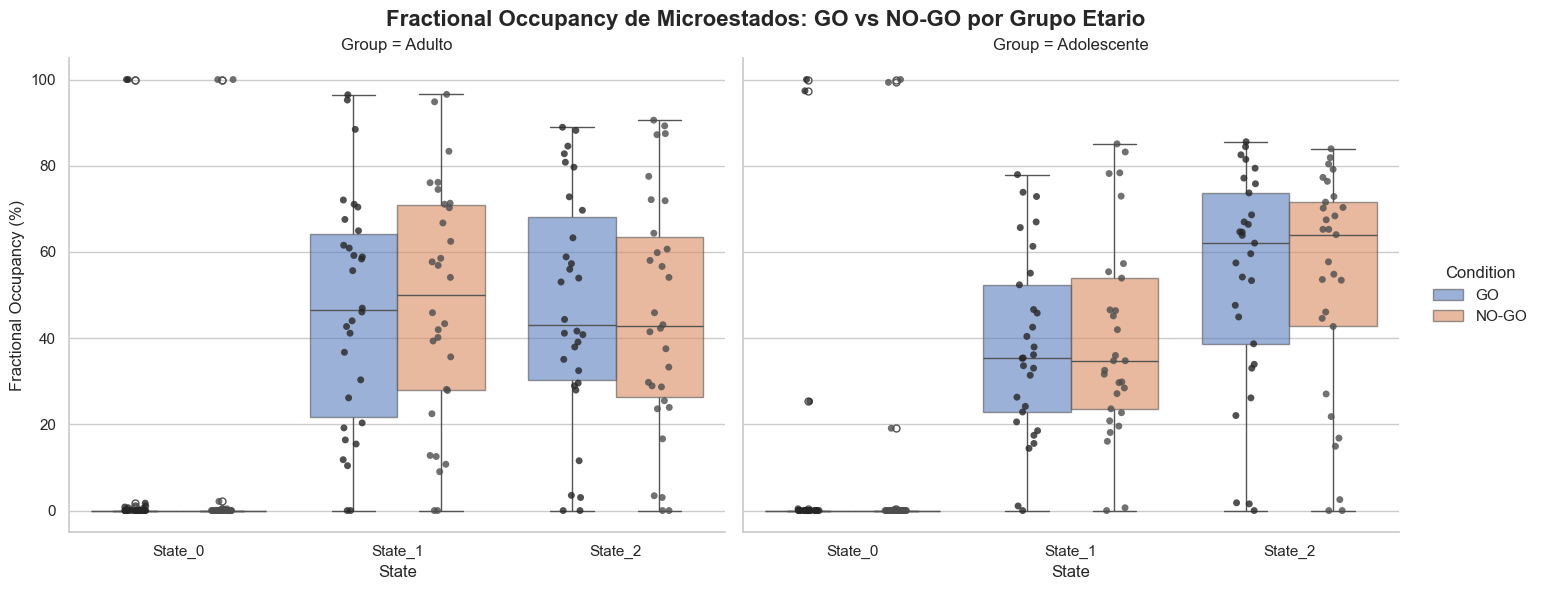

In [11]:
# Configurar estilo de Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Convertir el DataFrame a formato "largo" (Tidy) para que Seaborn lo pueda graficar fácilmente
df_melted = df_subjects.melt(
    id_vars=['Subject', 'Group', 'Condition'], 
    value_vars=[f'FO_State_{s}' for s in range(n_states)],
    var_name='State', 
    value_name='Fractional Occupancy (%)'
)

# Limpiar los nombres de los estados para la gráfica
df_melted['State'] = df_melted['State'].str.replace('FO_', '')

# GRAFICAR: GO vs NO-GO separando por Estado
g = sns.catplot(
    data=df_melted, 
    x='State', 
    y='Fractional Occupancy (%)', 
    hue='Condition', 
    col='Group', # Crea una columna para Adultos y otra para Adolescentes
    kind='box', 
    height=6, 
    aspect=1.2,
    boxprops={'alpha': 0.6}
)

# Añadir los puntos individuales para ver la dispersión real de tu muestra
g.map_dataframe(sns.stripplot, x='State', y='Fractional Occupancy (%)', hue='Condition', dodge=True, alpha=0.8, color=".3")

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Fractional Occupancy de Microestados: GO vs NO-GO por Grupo Etario", fontsize=16, fontweight='bold')
plt.show()

Cargando experimento: feat_task_k3_diag_pca90_bandsonly
Estados HMM: 3
Sujetos cargados: 118

Reconstruyendo épocas...

Ventanas por época detectadas: 61
GO: 1179 épocas
NOGO: 1180 épocas
ADULTO_GO: 599 épocas
ADULTO_NOGO: 600 épocas
ADOLESCENTE_GO: 580 épocas
ADOLESCENTE_NOGO: 580 épocas

TIME AXIS
Inicio real: -400.0 ms
Final real: 5600.0 ms


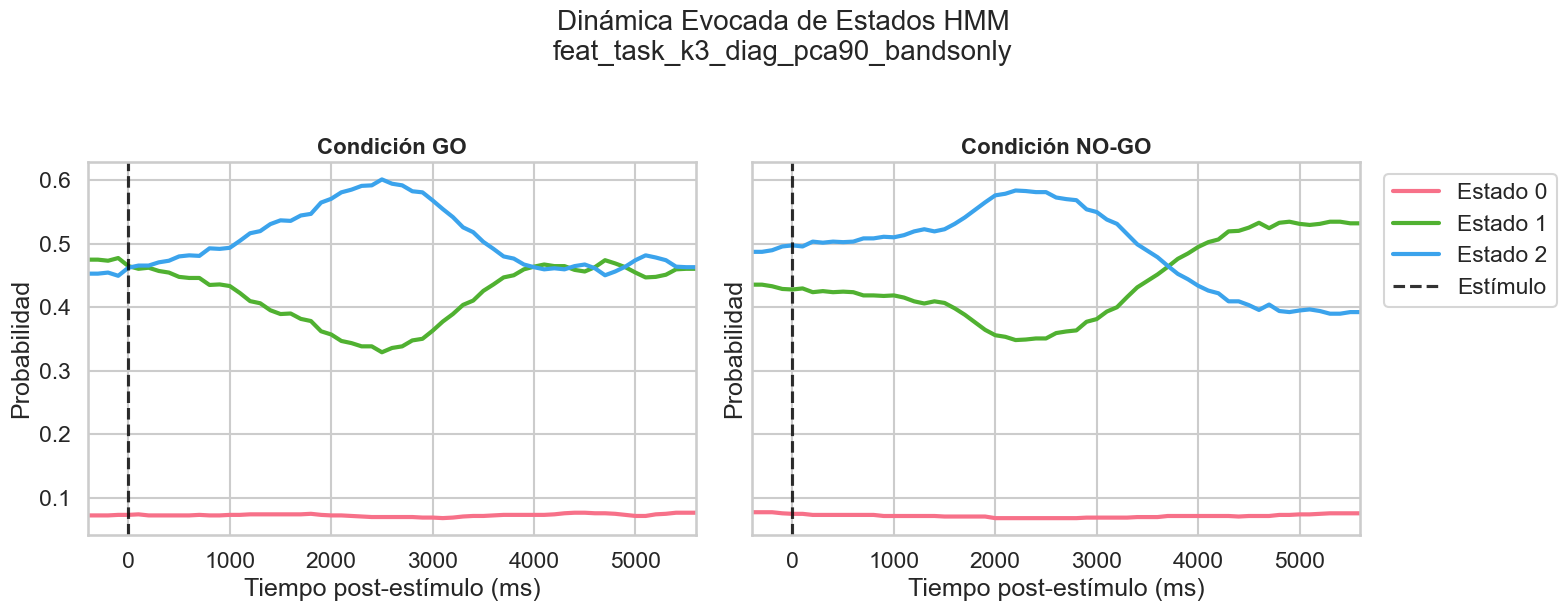

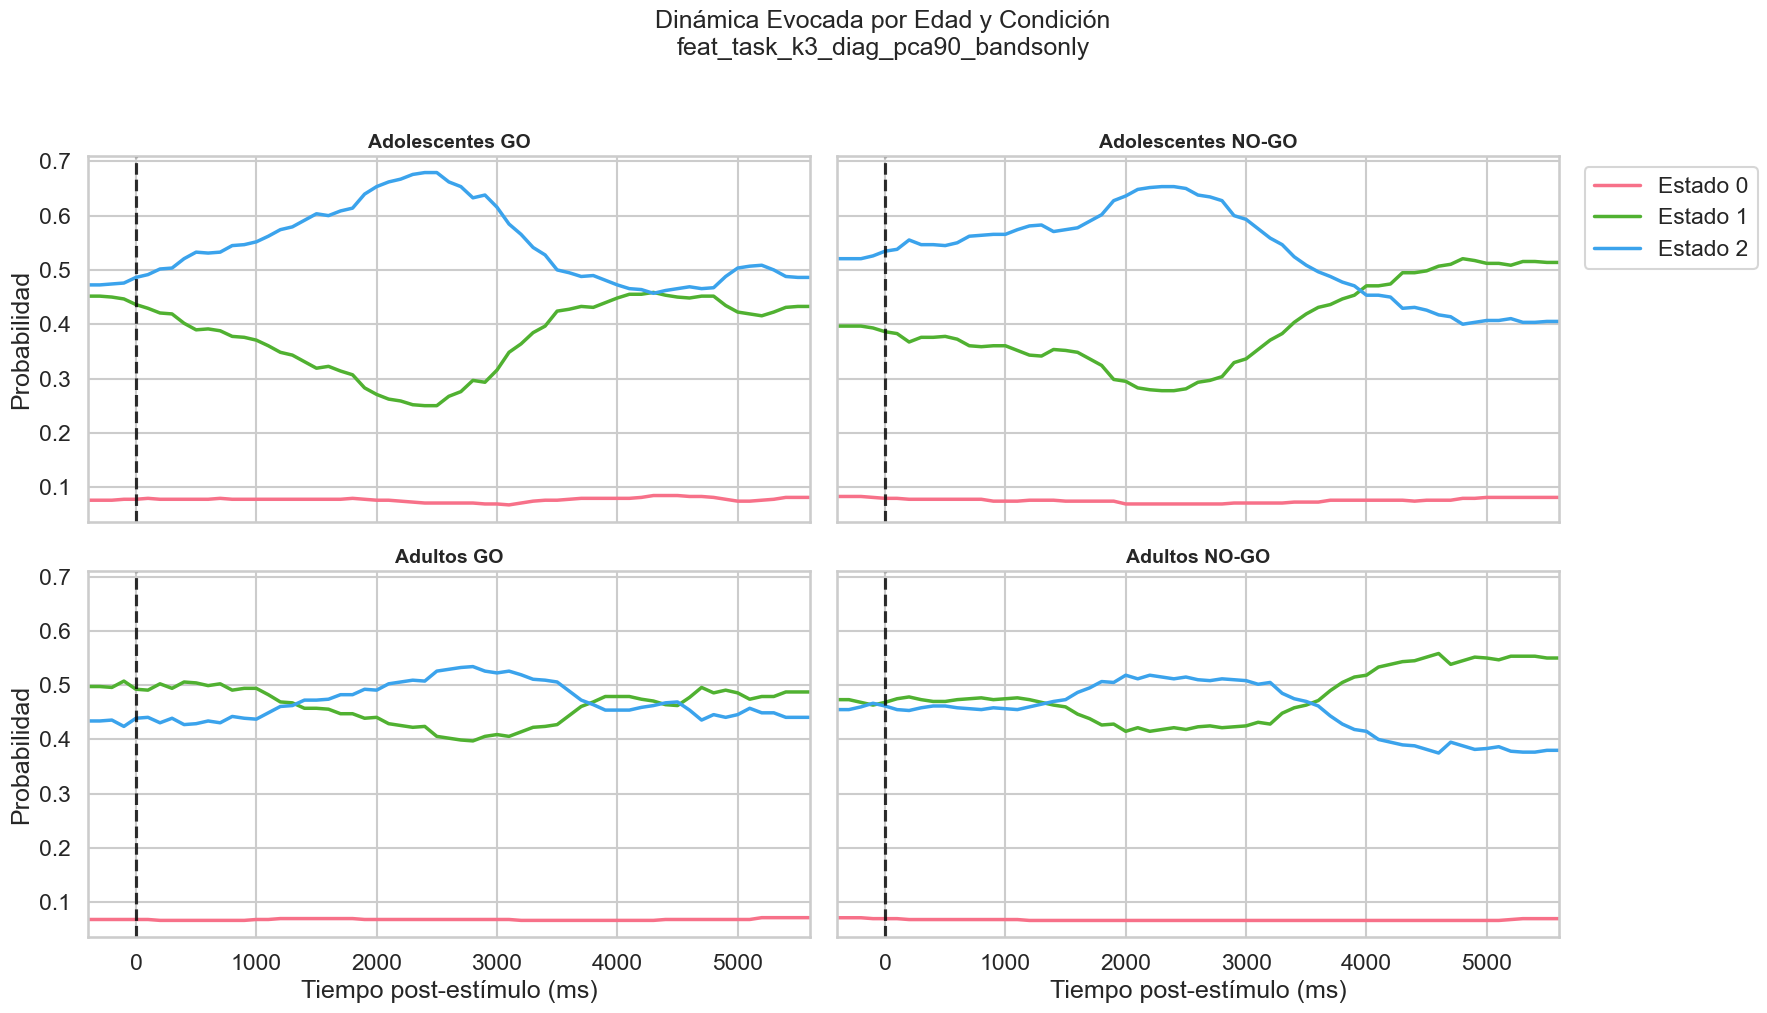


PEAK EVOKED PROBABILITIES


,Group,State,Peak Time (ms),Peak Probability
0,GO,0,4400.0,0.076336
1,GO,1,-100.0,0.477523
2,GO,2,2500.0,0.601357
3,NOGO,0,-400.0,0.077119
4,NOGO,1,4900.0,0.534746
5,NOGO,2,2200.0,0.583898
6,ADULTO_GO,0,5200.0,0.071786
7,ADULTO_GO,1,-100.0,0.507513
8,ADULTO_GO,2,2800.0,0.534224
9,ADULTO_NOGO,0,-400.0,0.071667


In [19]:
# ============================================================
# EVOKED STATE DYNAMICS (GO vs NO-GO)
# VERSIÓN CORREGIDA — ALINEACIÓN TEMPORAL REAL
# ============================================================

import os
import glob
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# ============================================================
# CONFIG
# ============================================================

CONFIG_PATH = "../../configs/experiments/feat_task_k3_diag_pca90_bandsonly.yaml"

# ------------------------------------------------------------
# PARÁMETROS TEMPORALES REALES
# ------------------------------------------------------------

EPOCH_START_MS = -500
WINDOW_SIZE_MS = 200
STEP_SIZE_MS = 100

LISTA_ADULTOS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN', 'GSASC', 'IJALSC',
    'JAGSSC', 'LHACSIN', 'MAEGLSC', 'MAHLSC', 'MFGSIN', 'MGOKSC',
    'RAMPSIN', 'SDBGSIN', 'VMRSIN', 'AVLLSC', 'BMPSC', 'CGMSIN',
    'CJGSIN', 'CPGSC', 'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN',
    'JGCSC', 'MGVGSC', 'RKACSC', 'SEOOSIN', 'TTOSC', 'VBPSIN'
]

# ============================================================
# LOAD EXPERIMENT
# ============================================================

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']
k = cfg['pipeline']['hmm']['k_states']

exp_dir = os.path.join(
    "../../outputs/processed/experiments/feature_hmm/task/",
    exp_name
)

features_dir = "../../data/interim/features/task/"

print("=" * 60)
print(f"Cargando experimento: {exp_name}")
print("=" * 60)

viterbi = np.load(
    os.path.join(exp_dir, f'viterbi_paths_k{k}.npy')
)

length_files = sorted(
    glob.glob(os.path.join(features_dir, '*_lengths.npy'))
)

print(f"Estados HMM: {k}")
print(f"Sujetos cargados: {len(length_files)}")

# ============================================================
# HELPERS
# ============================================================

def parse_subject_info(filename):

    clean_name = filename.upper()

    clean_name = clean_name.replace('_SIN_CONTEXTO', '')
    clean_name = clean_name.replace('_EPO', '')
    clean_name = clean_name.replace('_LENGTHS.NPY', '')
    clean_name = clean_name.replace('.NPY', '')

    if clean_name.endswith("NOGO"):
        condicion = "NOGO"
        subject_id_real = clean_name[:-4]

    elif clean_name.endswith("NG"):
        condicion = "NOGO"
        subject_id_real = clean_name[:-2]

    elif clean_name.endswith("GO"):
        condicion = "GO"
        subject_id_real = clean_name[:-2]

    else:
        condicion = "GO"
        subject_id_real = clean_name

    grupo = "ADOLESCENTE"

    for adulto in LISTA_ADULTOS:
        if subject_id_real.startswith(adulto):
            grupo = "ADULTO"
            break

    return subject_id_real, grupo, condicion


def calcular_probabilidades(matriz, n_states):

    if len(matriz) == 0:
        return np.zeros((n_states, WINDOWS_PER_EPOCH))

    probs = np.zeros((n_states, matriz.shape[1]))

    for s in range(n_states):
        probs[s] = np.mean(matriz == s, axis=0)

    return probs

# ============================================================
# RECONSTRUCCIÓN DE SECUENCIAS
# ============================================================

print("\nReconstruyendo épocas...")

secuencias_crudas = {
    "GO": [],
    "NOGO": [],
    "ADULTO_GO": [],
    "ADULTO_NOGO": [],
    "ADOLESCENTE_GO": [],
    "ADOLESCENTE_NOGO": []
}

start_idx = 0
todas_las_longitudes = []

for f_path in length_files:

    filename = os.path.basename(f_path)

    subject_id_real, grupo, condicion = parse_subject_info(filename)

    lengths = np.load(f_path)

    for ep_len in lengths:

        ep_path = viterbi[start_idx:start_idx + ep_len]

        start_idx += ep_len

        todas_las_longitudes.append(ep_len)

        secuencias_crudas[condicion].append(ep_path)

        secuencias_crudas[f"{grupo}_{condicion}"].append(ep_path)

# ============================================================
# DETECCIÓN AUTOMÁTICA DE TAMAÑO DE ÉPOCA
# ============================================================

WINDOWS_PER_EPOCH = Counter(
    todas_las_longitudes
).most_common(1)[0][0]

print(f"\nVentanas por época detectadas: {WINDOWS_PER_EPOCH}")

# ============================================================
# FILTRAR ÉPOCAS VÁLIDAS
# ============================================================

matrices = {}

for key, lista_epocas in secuencias_crudas.items():

    epocas_validas = [
        ep for ep in lista_epocas
        if len(ep) == WINDOWS_PER_EPOCH
    ]

    matrices[key] = np.array(epocas_validas)

    print(f"{key}: {len(epocas_validas)} épocas")

# ============================================================
# EJE TEMPORAL CORRECTO
# ============================================================

time_axis = (
    np.arange(WINDOWS_PER_EPOCH) * STEP_SIZE_MS
    + EPOCH_START_MS
    + (WINDOW_SIZE_MS / 2)
)

print("\n" + "=" * 60)
print("TIME AXIS")
print("=" * 60)

print(f"Inicio real: {time_axis[0]} ms")
print(f"Final real: {time_axis[-1]} ms")

# ============================================================
# PROBABILIDADES EVOCADAS
# ============================================================

probs = {
    key: calcular_probabilidades(value, k)
    for key, value in matrices.items()
}

# ============================================================
# PLOT 1 — GO vs NOGO
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

colors = sns.color_palette("husl", k)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True,
    sharex=True
)

paneles = [
    ("GO", "Condición GO"),
    ("NOGO", "Condición NO-GO")
]

for ax, (key, title) in zip(axes, paneles):

    matriz = probs[key]

    for s in range(k):

        ax.plot(
            time_axis,
            matriz[s],
            lw=3,
            label=f"Estado {s}",
            color=colors[s]
        )

    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel("Tiempo post-estímulo (ms)")
    ax.set_ylabel("Probabilidad")

    # ESTÍMULO REAL
    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black',
        label='Estímulo'
    )

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Dinámica Evocada de Estados HMM\n{exp_name}",
    fontsize=20,
    y=1.03
)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2 — MATRIZ 2x2 DESARROLLO
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 10),
    sharex=True,
    sharey=True
)

config_panels = [
    (0, 0, "ADOLESCENTE_GO", "Adolescentes GO"),
    (0, 1, "ADOLESCENTE_NOGO", "Adolescentes NO-GO"),
    (1, 0, "ADULTO_GO", "Adultos GO"),
    (1, 1, "ADULTO_NOGO", "Adultos NO-GO")
]

for row, col, key, title in config_panels:

    ax = axes[row, col]

    matriz = probs[key]

    for s in range(k):

        ax.plot(
            time_axis,
            matriz[s],
            lw=2.5,
            label=f"Estado {s}",
            color=colors[s]
        )

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black'
    )

    if row == 1:
        ax.set_xlabel("Tiempo post-estímulo (ms)")

    if col == 0:
        ax.set_ylabel("Probabilidad")

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[0,1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Dinámica Evocada por Edad y Condición\n{exp_name}",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# MÉTRICAS TEMPORALES RESUMEN
# ============================================================

print("\n" + "=" * 60)
print("PEAK EVOKED PROBABILITIES")
print("=" * 60)

summary = []

for group_name, matrix in probs.items():

    if matrix.shape[1] == 0:
        continue

    for s in range(k):

        peak_idx = np.argmax(matrix[s])

        peak_time = time_axis[peak_idx]

        peak_prob = matrix[s, peak_idx]

        summary.append({
            'Group': group_name,
            'State': s,
            'Peak Time (ms)': peak_time,
            'Peak Probability': peak_prob
        })

df_summary = pd.DataFrame(summary)

display(df_summary)